The objective of this notebook is to verify data before join the fish distribution dataset (lat, long, time) with the environment variables from Copernius.

To simplify process, I get filter time range 1/1/2025 -> 31/1/2025 
- Data from Copernius is downloaded based on this tutorial guide: https://help.marine.copernicus.eu/en/articles/8287609-copernicus-marine-toolbox-api-open-a-dataset-or-read-a-dataframe-remotely
- Fish data distribution is from GBIF 

Then I will verify some assumptions:
- The longitude is belong to [-180, 180] or [0-360]?
- The variables exist in the dataset_id or not? Which dataset_id to get thetao, uo, vo,...
- Are there some missing datas in environment from Copernius? Why when I join there are some missing, null data
- How to join exactly

In [ ]:
##Copernius Request dataframe example code
# request_dataframe = copernicusmarine.read_dataframe(
#     dataset_id = "cmems_mod_glo_phy-thetao_anfc_0.083deg_P1D-m",
#     minimum_longitude=27.24,
#     maximum_longitude=141.57,
#     minimum_latitude=-10.77,
#     maximum_latitude=37.74,
#     variables = ["thetao"],

#     minimum_depth=0.0,
#     maximum_depth=1.0,

#     start_datetime="2025-01-01",
#     end_datetime="2025-01-31",
# )

In [82]:
import pandas as pd
import numpy as np

data_path = "../dataset/env_copernius/thetao_20250101_20250131.csv"
thetao_data = pd.read_csv(data_path)
print(thetao_data.shape)

(24753624, 5)


In [83]:
print(thetao_data.columns)

Index(['depth', 'latitude', 'longitude', 'time', 'thetao'], dtype='object')


In [84]:
print(thetao_data.describe())

              depth      latitude     longitude        thetao
count  2.475362e+07  2.475362e+07  2.475362e+07  1.379785e+07
mean   4.940250e-01  1.345834e+01  8.437501e+01  2.695517e+01
std    7.166717e-11  1.400072e+01  3.300518e+01  3.751165e+00
min    4.940250e-01 -1.075000e+01  2.725000e+01 -6.522925e-02
25%    4.940250e-01  1.333336e+00  5.581251e+01  2.601096e+01
50%    4.940250e-01  1.345834e+01  8.437502e+01  2.828310e+01
75%    4.940250e-01  2.558334e+01  1.129375e+02  2.915962e+01
max    4.940250e-01  3.766667e+01  1.415000e+02  3.220472e+01


In [85]:
#Get min, max of longitude
print("Longitude range:", thetao_data["longitude"].min(), "to", thetao_data["longitude"].max())

Longitude range: 27.25 to 141.5


Hệ tọa độ của dữ liệu lat, long là gì?
- Latitude luôn là [-90, 90]
- Longtitude có thể có 2 hệ [-180, 180] và [0,360]. Mục đích kiểm tra max, min để đảm bảo thuộc hệ nào, hic, nhưng Longitude là 27.25 đến 141.5 thì không thể loại trừ, nhưng theo source thì 90% copernius là hệ 0-360. trong khi hệ của dữ liệu gbif có khả năng là [-180, 180]

In [86]:
# import matplotlib.pyplot as plt

# plt.figure()
# plt.hist2d(thetao_data["longitude"], thetao_data["latitude"], weights=thetao_data["thetao"], bins=100)
# plt.colorbar(label="Thetao")
# plt.xlabel("Longitude")
# plt.ylabel("Latitude")
# plt.title("Spatial Heatmap")
# plt.show()

In [87]:
#check for missing values
missing_values = thetao_data.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
depth               0
latitude            0
longitude           0
time                0
thetao       10955772
dtype: int64


In [88]:
print(10955772/24753624)

0.44259264825223166


In [89]:
# Filter out rows with just null values in 'thetao' column
thetao_null = thetao_data.loc[thetao_data["thetao"].isna()]

In [90]:
print(thetao_null.shape)

(10955772, 5)


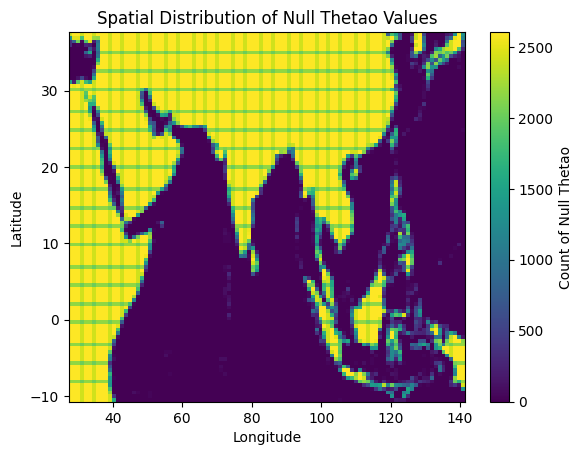

In [91]:
# Distribution of thetao_null
import matplotlib.pyplot as plt
plt.figure()
plt.hist2d(thetao_null["longitude"], thetao_null["latitude"], bins=100)
plt.colorbar(label="Count of Null Thetao")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Null Thetao Values")
plt.show()

Vậy là, khi lấy dữ liệu thetao (trong khoảng 1 tháng từ 1/1/2025 đến 31/1/2025) về theotao từ copernius có khoảng 44.25% là các giá trị null, thì các giá trị này thuộc vào đất liền. 

Nghĩa là:

1/ Có cách nào optimize lưu trữ, khi lấy dữ liệu từ copernius về lưu .nc hay không? Vì 50% lưu trong tọa độ này đều là đất liền, giá trị thetao đều null

2/ Việc khi join dữ liệu lat, long, time (trong dataset cá) từ gbif join và trả về null thetao, thì khả năng cao là bị lỗi do lệch tọa độ lat, long, và dẫn đến khi join vào thì trả về các dữ liệu môi trường đều là null

/var/folders/yt/4vlc63d57rz84q0w40rbc23w0000gn/T/ipykernel_39001/636630184.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  thetao_null["day"] = pd.to_datetime(thetao_null["time"]).dt.day


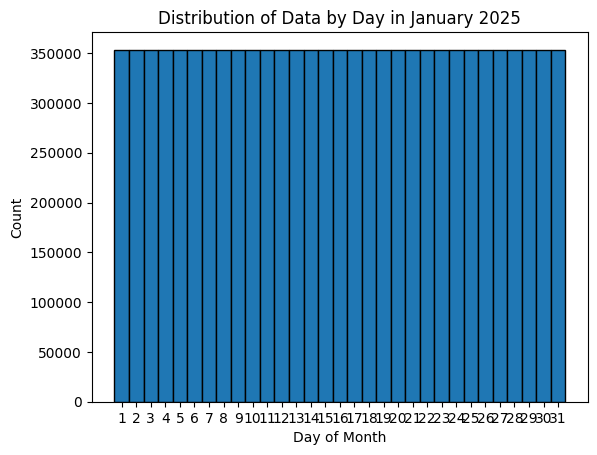

In [92]:
# Convert to day column
thetao_null["day"] = pd.to_datetime(thetao_null["time"]).dt.day
# Distribution by day of the data_thetao
import matplotlib.pyplot as plt
plt.figure()
plt.hist(thetao_null["day"], bins=np.arange(1, 33)-0.5, edgecolor='black')
plt.xlabel("Day of Month")
plt.ylabel("Count")
plt.title("Distribution of Data by Day in January 2025")
plt.xticks(range(1, 32))
plt.show()

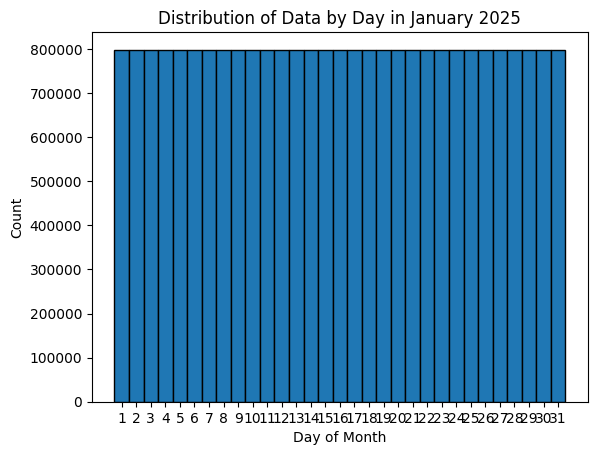

In [93]:
# Convert to day column
thetao_data["day"] = pd.to_datetime(thetao_data["time"]).dt.day
# Distribution by day of the data_thetao
import matplotlib.pyplot as plt
plt.figure()
plt.hist(thetao_data["day"], bins=np.arange(1, 33)-0.5, edgecolor='black')
plt.xlabel("Day of Month")
plt.ylabel("Count")
plt.title("Distribution of Data by Day in January 2025")
plt.xticks(range(1, 32))
plt.show()

# EDA dữ liệu phân bổ cá
Filter theo tháng 1/2025 dữ liệu cá có được, và kiểm tra:
- Hệ longitude thuộc hệ nào
- Thử mapping lat, long normalize (theo nearest) để lấy dữ liệu env từ copernius

In [94]:
fish_2025_path = pd.read_csv("../dataset/gbif_five_species_asia_cleaned.csv")
fish_2025_jan = fish_2025_path.loc[(fish_2025_path["year"]==2025) & (fish_2025_path["month"]==1)]
print(fish_2025_jan.shape)

(10, 21)


In [95]:
print(fish_2025_jan.head(5))

                               scientificName  taxonKey  individualCount  \
506  Scomberomorus commerson (Lacepède, 1800)   2374255              NaN   
507  Scomberomorus commerson (Lacepède, 1800)   2374255              NaN   
508  Scomberomorus commerson (Lacepède, 1800)   2374255              1.0   
509  Scomberomorus commerson (Lacepède, 1800)   2374255              1.0   
510  Scomberomorus commerson (Lacepède, 1800)   2374255              1.0   

     organismQuantity organismQuantityType  sex lifeStage occurrenceStatus  \
506               NaN                  NaN  NaN       NaN          PRESENT   
507               NaN                  NaN  NaN  Juvenile          PRESENT   
508               NaN                  NaN  NaN       NaN          PRESENT   
509               NaN                  NaN  NaN       NaN          PRESENT   
510               NaN                  NaN  NaN       NaN          PRESENT   

    continent countryCode  ... island decimalLatitude  decimalLongitude  \

In [96]:
#Get min, max of longitude
print("Longitude range:", fish_2025_jan["decimalLongitude"].min(), "to", fish_2025_jan["decimalLongitude"].max())

Longitude range: 34.654536 to 122.259797


Khi test dữ liệu cá toàn thế giới thì Longitude của fish lấy từ GBIF chắc chắn là từ hệ [-180, 180]

In [97]:
# Convert Longitude from [-180, 180] to [0, 360]
fish_2025_jan["Longitude_360"] = fish_2025_jan["decimalLongitude"] % 360

print(fish_2025_jan.head(5))

                               scientificName  taxonKey  individualCount  \
506  Scomberomorus commerson (Lacepède, 1800)   2374255              NaN   
507  Scomberomorus commerson (Lacepède, 1800)   2374255              NaN   
508  Scomberomorus commerson (Lacepède, 1800)   2374255              1.0   
509  Scomberomorus commerson (Lacepède, 1800)   2374255              1.0   
510  Scomberomorus commerson (Lacepède, 1800)   2374255              1.0   

     organismQuantity organismQuantityType  sex lifeStage occurrenceStatus  \
506               NaN                  NaN  NaN       NaN          PRESENT   
507               NaN                  NaN  NaN  Juvenile          PRESENT   
508               NaN                  NaN  NaN       NaN          PRESENT   
509               NaN                  NaN  NaN       NaN          PRESENT   
510               NaN                  NaN  NaN       NaN          PRESENT   

    continent countryCode  ... decimalLatitude decimalLongitude  elevation

/var/folders/yt/4vlc63d57rz84q0w40rbc23w0000gn/T/ipykernel_39001/3258954694.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fish_2025_jan["Longitude_360"] = fish_2025_jan["decimalLongitude"] % 360


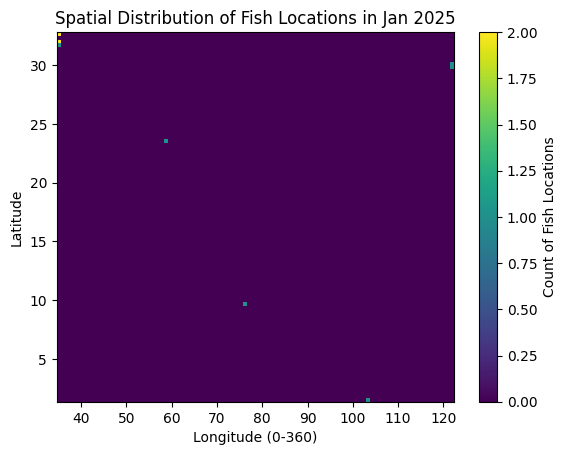

In [98]:
# Distribution of fish locations
import matplotlib.pyplot as plt
plt.figure()
plt.hist2d(fish_2025_jan["Longitude_360"], fish_2025_jan["decimalLatitude"], bins=100)
plt.colorbar(label="Count of Fish Locations")
plt.xlabel("Longitude (0-360)")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Fish Locations in Jan 2025")
plt.show()

In [99]:
import pandas as pd

# 2. Chuẩn hóa cột thời gian (chuyển về dạng YYYY-MM-DD)
# Giả sử tên cột thời gian là 'time'
thetao_data['date_key'] = pd.to_datetime(thetao_data['time']).dt.date
fish_2025_jan['date_key'] = pd.to_datetime(fish_2025_jan['eventDate'], format='ISO8601').dt.date

# 3. Làm tròn tọa độ (ví dụ lấy 5 chữ số thập phân)
# Giả sử tên cột là 'latitude' và 'longitude'
res = 0.25  # độ phân giải của dữ liệu môi trường
thetao_data['lat_key'] = (thetao_data['latitude']/ res).round() * res
thetao_data['lon_key'] = (thetao_data['longitude']/ res).round() * res

fish_2025_jan['lat_key'] = (fish_2025_jan['decimalLatitude']/ res).round() * res
fish_2025_jan['lon_key'] = (fish_2025_jan['Longitude_360']/ res).round() * res

/var/folders/yt/4vlc63d57rz84q0w40rbc23w0000gn/T/ipykernel_39001/167646787.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fish_2025_jan['date_key'] = pd.to_datetime(fish_2025_jan['eventDate'], format='ISO8601').dt.date
/var/folders/yt/4vlc63d57rz84q0w40rbc23w0000gn/T/ipykernel_39001/167646787.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fish_2025_jan['lat_key'] = (fish_2025_jan['decimalLatitude']/ res).round() * res
/var/folders/yt/4vlc63d57rz84q0w40rbc23w0000gn/T/ipykernel_39001/167646787.py:1

In [100]:
print(thetao_data.head())

      depth  latitude  longitude        time  thetao  day    date_key  \
0  0.494025    -10.75      27.25  2025-01-01     NaN    1  2025-01-01   
1  0.494025    -10.75      27.25  2025-01-02     NaN    2  2025-01-02   
2  0.494025    -10.75      27.25  2025-01-03     NaN    3  2025-01-03   
3  0.494025    -10.75      27.25  2025-01-04     NaN    4  2025-01-04   
4  0.494025    -10.75      27.25  2025-01-05     NaN    5  2025-01-05   

   lat_key  lon_key  
0   -10.75    27.25  
1   -10.75    27.25  
2   -10.75    27.25  
3   -10.75    27.25  
4   -10.75    27.25  


In [101]:
print(fish_2025_jan.head())

                               scientificName  taxonKey  individualCount  \
506  Scomberomorus commerson (Lacepède, 1800)   2374255              NaN   
507  Scomberomorus commerson (Lacepède, 1800)   2374255              NaN   
508  Scomberomorus commerson (Lacepède, 1800)   2374255              1.0   
509  Scomberomorus commerson (Lacepède, 1800)   2374255              1.0   
510  Scomberomorus commerson (Lacepède, 1800)   2374255              1.0   

     organismQuantity organismQuantityType  sex lifeStage occurrenceStatus  \
506               NaN                  NaN  NaN       NaN          PRESENT   
507               NaN                  NaN  NaN  Juvenile          PRESENT   
508               NaN                  NaN  NaN       NaN          PRESENT   
509               NaN                  NaN  NaN       NaN          PRESENT   
510               NaN                  NaN  NaN       NaN          PRESENT   

    continent countryCode  ... elevationAccuracy  \
506      ASIA         

In [102]:
# Check giả thuyết bouding box, lat long của 2 csv không có liên quan nhau
def get_bbox(df, lat_col, lon_col):
    return {
        'min_lat': df[lat_col].min(),
        'max_lat': df[lat_col].max(),
        'min_lon': df[lon_col].min(),
        'max_lon': df[lon_col].max()
    }

bbox1 = get_bbox(thetao_data, 'latitude', 'longitude')
bbox2 = get_bbox(fish_2025_jan, 'decimalLatitude', 'Longitude_360')

print(f"BBox 1 - Dữ liệu môi trường thetao: {bbox1}")
print(f"BBox 2 - Dữ liệu phân bổ cá tháng 1/2025: {bbox2}")

BBox 1 - Dữ liệu môi trường thetao: {'min_lat': -10.75, 'max_lat': 37.66667, 'min_lon': 27.25, 'max_lon': 141.5}
BBox 2 - Dữ liệu phân bổ cá tháng 1/2025: {'min_lat': 1.346429, 'max_lat': 32.825866, 'min_lon': 34.654536, 'max_lon': 122.259797}


Toàn bộ dữ liệu bounding box của phân bổ cá 1/2025 nằm gọn trong bounding box lấy dữ liệu môi trường từ copernius

Lesson learned: Dữ liệu môi trường thường là dạng lưới grid với bước nhảy cố định, mỗi 0.25 độ có một điểm dữ liệu, dữ liệu cá thường là tọa độ cụ thể
=> Để merge khớp hoàn toàn, ko nên (exact match) mà nên làm tròn tọa độ của cá lat long cụ thể về grid có độ phân giải với file môi trường
Cả dữ liệu môi trường cũng phải nhảy bước về 0.25 nếu chỉ làm tròn số thập phân thì vẫn chưa match

In [103]:
# 4. Thực hiện Mapping (Merge)
# 'inner' sẽ lấy những dòng xuất hiện ở cả 2 file dựa trên tọa độ và ngày
result = pd.merge(
    thetao_data, 
    fish_2025_jan, 
    left_on=['lat_key', 'lon_key', 'date_key'], 
    right_on=['lat_key', 'lon_key', 'date_key'],
    how='inner',
    suffixes=('_file1', '_file2')
)

# 5. Xóa các cột key tạm nếu không cần thiết
result = result.drop(columns=['lat_key', 'lon_key', 'date_key'])

print(result.head())

      depth  latitude  longitude        time     thetao  day_file1  \
0  0.494025  1.166672  103.66669  2025-01-18  27.754972         18   
1  0.494025  1.166672  103.75000  2025-01-18  27.759804         18   
2  0.494025  1.166672  103.83334  2025-01-18  27.741377         18   
3  0.494025  1.250000  103.66669  2025-01-18  27.744446         18   
4  0.494025  1.250000  103.75000  2025-01-18  27.761750         18   

                             scientificName  taxonKey  individualCount  \
0  Scomberomorus commerson (Lacepède, 1800)   2374255              NaN   
1  Scomberomorus commerson (Lacepède, 1800)   2374255              NaN   
2  Scomberomorus commerson (Lacepède, 1800)   2374255              NaN   
3  Scomberomorus commerson (Lacepède, 1800)   2374255              NaN   
4  Scomberomorus commerson (Lacepède, 1800)   2374255              NaN   

   organismQuantity  ... decimalLatitude decimalLongitude elevation  \
0               NaN  ...        1.346429       103.856472      

In [104]:
print(result.describe())

              depth   latitude   longitude     thetao  day_file1  \
count  9.000000e+01  90.000000   90.000000  58.000000  90.000000   
mean   4.940250e-01  25.575002   65.725007  19.481790   9.600000   
std    4.465771e-16  10.645513   35.928974   6.886319   6.940842   
min    4.940250e-01   1.166672   34.666670   9.591122   2.000000   
25%    4.940250e-01  23.500000   34.833344  11.020827   3.000000   
50%    4.940250e-01  31.000004   46.750007  19.550908   8.000000   
75%    4.940250e-01  32.250000  103.750000  26.835466  15.000000   
max    4.940250e-01  32.833336  122.333340  29.688349  22.000000   

           taxonKey  individualCount  organismQuantity  decimalLatitude  \
count  9.000000e+01             45.0               0.0        90.000000   
mean   2.377262e+06              1.0               NaN        25.624237   
std    6.108754e+03              0.0               NaN        10.625355   
min    2.374013e+06              1.0               NaN         1.346429   
25%    2.374

In [105]:
print(result.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   depth                          90 non-null     float64
 1   latitude                       90 non-null     float64
 2   longitude                      90 non-null     float64
 3   time                           90 non-null     object 
 4   thetao                         58 non-null     float64
 5   day_file1                      90 non-null     int32  
 6   scientificName                 90 non-null     object 
 7   taxonKey                       90 non-null     int64  
 8   individualCount                45 non-null     float64
 9   organismQuantity               0 non-null      float64
 10  organismQuantityType           0 non-null      object 
 11  sex                            0 non-null      object 
 12  lifeStage                      18 non-null     objec

Tại sao vẫn có 57 giá trị the tao non-null?

In [106]:
print(result.shape)

(90, 28)


Dữ liệu cá ban đầu là (10, 21) vì sao sau khi join xong với dữ liệu môi trường thì lại xuất hiện ra (90,30) gấp 9 lần số lượng dòng?

In [107]:
# Kiểm tra xem có bao nhiêu dòng trùng lặp key trong file môi trường
duplicates = thetao_data.duplicated(subset=['lat_key', 'lon_key', 'date_key']).sum()
print(f"Số dòng trùng lặp key trong môi trường: {duplicates}")

# Xem thử một ví dụ bị trùng
if duplicates > 0:
    print(thetao_data[thetao_data.duplicated(subset=['lat_key', 'lon_key', 'date_key'], keep=False)].sort_values(['lat_key', 'lon_key', 'date_key']).head(10))

Số dòng trùng lặp key trong môi trường: 21985014
          depth   latitude  longitude        time  thetao  day    date_key  \
0      0.494025 -10.750000  27.250000  2025-01-01     NaN    1  2025-01-01   
31     0.494025 -10.750000  27.333344  2025-01-01     NaN    1  2025-01-01   
42532  0.494025 -10.666664  27.250000  2025-01-01     NaN    1  2025-01-01   
42563  0.494025 -10.666664  27.333344  2025-01-01     NaN    1  2025-01-01   
1      0.494025 -10.750000  27.250000  2025-01-02     NaN    2  2025-01-02   
32     0.494025 -10.750000  27.333344  2025-01-02     NaN    2  2025-01-02   
42533  0.494025 -10.666664  27.250000  2025-01-02     NaN    2  2025-01-02   
42564  0.494025 -10.666664  27.333344  2025-01-02     NaN    2  2025-01-02   
2      0.494025 -10.750000  27.250000  2025-01-03     NaN    3  2025-01-03   
33     0.494025 -10.750000  27.333344  2025-01-03     NaN    3  2025-01-03   

       lat_key  lon_key  
0       -10.75    27.25  
31      -10.75    27.25  
42532   -10.75

Sau khi in ra thì mình phát hiện bị duplicate dữ liệu do khi rounding lấy dữ liệu lat_key, lon_key rounding.

Giải pháp sẽ là có thể hoặc lấy giá trị đầu tiên hoặc lấy mean thetao trong khi cùng một lat_key, lon_key

In [108]:
# Filter thetao_data with just some columns
thetao_filtered = thetao_data[['lat_key', 'lon_key', 'date_key', 'thetao']]
thetao_clean = thetao_filtered.groupby(['lat_key', 'lon_key', 'date_key'], as_index=False)['thetao'].mean()

In [109]:
print(thetao_data.shape)

(24753624, 9)


In [110]:
print(thetao_clean.shape)

(2768610, 4)


In [111]:
# Kiểm tra xem có bao nhiêu dòng trùng lặp key trong file môi trường
duplicates_after = thetao_clean.duplicated(subset=['lat_key', 'lon_key', 'date_key']).sum()
print(f"Số dòng trùng lặp key trong môi trường: {duplicates_after}")

Số dòng trùng lặp key trong môi trường: 0


Great!!!! I made it. Now it's time to merge data again thetao_clean with fish_2025_jan

In [112]:
result_clean = pd.merge(
    thetao_clean, 
    fish_2025_jan, 
    left_on=['lat_key', 'lon_key', 'date_key'], 
    right_on=['lat_key', 'lon_key', 'date_key'],
    how='inner',
    suffixes=('_file1', '_file2')
)

# 5. Xóa các cột key tạm nếu không cần thiết
result_clean = result_clean.drop(columns=['lat_key', 'lon_key', 'date_key'])

print(result_clean.head(10))

      thetao                                  scientificName  taxonKey  \
0  27.766033        Scomberomorus commerson (Lacepède, 1800)   2374255   
1  29.524075        Scomberomorus commerson (Lacepède, 1800)   2374255   
2  23.928129            Thunnus albacares (Bonnaterre, 1788)   2374013   
3  10.917662              Trichiurus lepturus Linnaeus, 1758   2389407   
4  10.201037  Trichiurus japonicus Temminck & Schlegel, 1844   2389414   
5        NaN        Scomberomorus commerson (Lacepède, 1800)   2374255   
6  19.480542        Scomberomorus commerson (Lacepède, 1800)   2374255   
7  19.957365        Scomberomorus commerson (Lacepède, 1800)   2374255   
8  19.367868        Scomberomorus commerson (Lacepède, 1800)   2374255   
9  18.984407        Scomberomorus commerson (Lacepède, 1800)   2374255   

   individualCount  organismQuantity organismQuantityType  sex lifeStage  \
0              NaN               NaN                  NaN  NaN  Juvenile   
1              NaN               

In [114]:
# Save to csv file with 10 rows
result_clean.to_csv("../dataset/fish_env_thetao_jan2025.csv", index=True)

In [113]:
print(result_clean.shape)

(10, 23)


In conclusion:

- GBIF fish distribution, the longitude is in range [-180, 180] while the longitude of Copernius is from [0 , 360]
- thetao is belong to dataset_id: and environmental variables is just in the ocean. Not in the land. If I join two dataset with lat, long, time, there is missing, it might be wrong in the land.
- To join two dataset, we need to normalize lat, long data of fish distribution into step of grid of 0.25. Because the lat, long of copernius is in grid with step of 0.25. As a result, it might duplicate after normalize => we could average to a point from this grid.

# Exploration of Copernius api source


In [115]:
import copernicusmarine

/Users/phuongnguyen/anaconda3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Check thử dữ liệu lấy từ copernius marine api dataframe có giống với dữ liệu .nc tải về không?
